In [1]:
import pandas as pd

customers = pd.read_csv("customers.csv")
sales = pd.read_csv("sales_data.csv")
inventory = pd.read_csv("inventory.csv")

customers.head()

,Customer_ID,Age,Gender,Location,Subscription_Status,Previous_Purchases,Review_Rating,Churn
0,1,56,Male,New York,Yes,20,2.5,1
1,2,69,Male,California,Yes,53,2.1,1
2,3,46,Male,Illinois,Yes,20,4.3,1
3,4,32,Female,Illinois,Yes,7,3.8,0
4,5,60,Male,Texas,No,48,4.1,0


In [1]:
customers.info()

NameError: name 'customers' is not defined

In [2]:
customers.describe()

NameError: name 'customers' is not defined

In [3]:
import pandas as pd

customers = pd.read_csv("customers.csv")
sales = pd.read_csv("sales_data.csv")
inventory = pd.read_csv("inventory.csv")

In [4]:
customers.head()

,Customer_ID,Age,Gender,Location,Subscription_Status,Previous_Purchases,Review_Rating,Churn
0,1,56,Male,New York,Yes,20,2.5,1
1,2,69,Male,California,Yes,53,2.1,1
2,3,46,Male,Illinois,Yes,20,4.3,1
3,4,32,Female,Illinois,Yes,7,3.8,0
4,5,60,Male,Texas,No,48,4.1,0


In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          1000 non-null   int64  
 1   Age                  1000 non-null   int64  
 2   Gender               1000 non-null   object 
 3   Location             1000 non-null   object 
 4   Subscription_Status  1000 non-null   object 
 5   Previous_Purchases   1000 non-null   int64  
 6   Review_Rating        1000 non-null   float64
 7   Churn                1000 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 62.6+ KB


In [6]:
customers.describe()

,Customer_ID,Age,Previous_Purchases,Review_Rating,Churn
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.81900,29.614000,3.456400,0.202000
std,288.819436,14.99103,17.742824,0.863785,0.401693
min,1.000000,18.00000,0.000000,2.000000,0.000000
25%,250.750000,31.00000,14.000000,2.700000,0.000000
50%,500.500000,44.00000,29.000000,3.400000,0.000000
75%,750.250000,56.00000,46.000000,4.200000,0.000000
max,1000.000000,69.00000,59.000000,5.000000,1.000000


In [7]:
customers.isnull().sum()

Customer_ID            0
Age                    0
Gender                 0
Location               0
Subscription_Status    0
Previous_Purchases     0
Review_Rating          0
Churn                  0
dtype: int64

In [8]:
customers.dtypes

Customer_ID              int64
Age                      int64
Gender                  object
Location                object
Subscription_Status     object
Previous_Purchases       int64
Review_Rating          float64
Churn                    int64
dtype: object

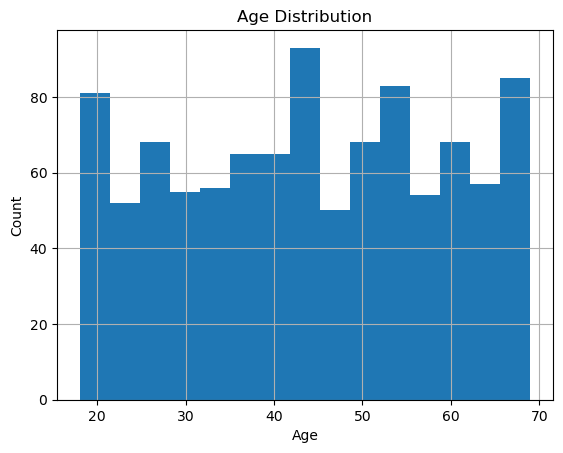

In [9]:
import matplotlib.pyplot as plt

customers['Age'].hist(bins=15)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

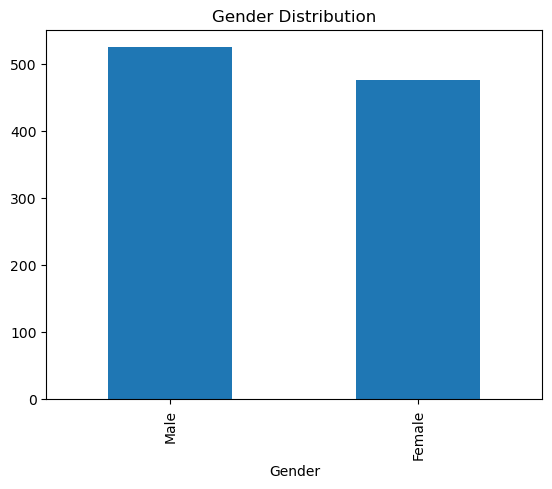

In [10]:
customers['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.show()

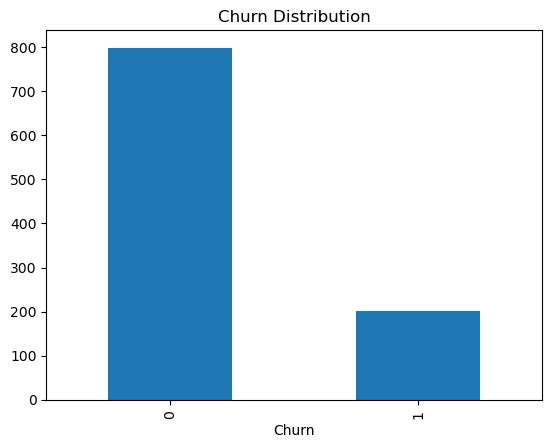

In [11]:
customers['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.show()

In [12]:
numeric_cols = customers.select_dtypes(include=['int64','float64'])
numeric_cols.corr()

,Customer_ID,Age,Previous_Purchases,Review_Rating,Churn
Customer_ID,1.000000,-0.011816,-0.005477,-0.011515,-0.000164
Age,-0.011816,1.000000,-0.018354,0.031401,0.034337
Previous_Purchases,-0.005477,-0.018354,1.000000,-0.004463,-0.015313
Review_Rating,-0.011515,0.031401,-0.004463,1.000000,-0.074699
Churn,-0.000164,0.034337,-0.015313,-0.074699,1.000000


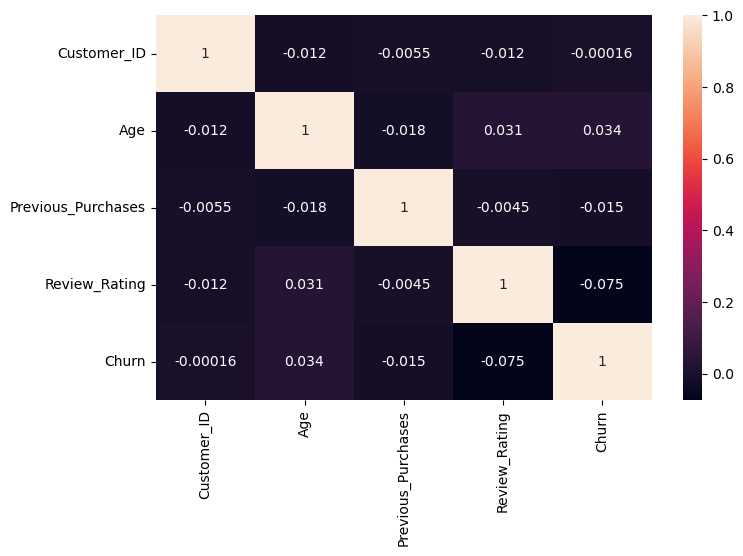

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(numeric_cols.corr(), annot=True)
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

X = customers[['Age','Previous_Purchases','Review_Rating']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

customers['Cluster'] = kmeans.fit_predict(X_scaled)

customers.head()

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,Customer_ID,Age,Gender,Location,Subscription_Status,Previous_Purchases,Review_Rating,Churn,Cluster
0,1,56,Male,New York,Yes,20,2.5,1,3
1,2,69,Male,California,Yes,53,2.1,1,0
2,3,46,Male,Illinois,Yes,20,4.3,1,1
3,4,32,Female,Illinois,Yes,7,3.8,0,1
4,5,60,Male,Texas,No,48,4.1,0,0


In [16]:
customers[['Customer_ID','Cluster']].head()

,Customer_ID,Cluster
0,1,3
1,2,0
2,3,1
3,4,1
4,5,0


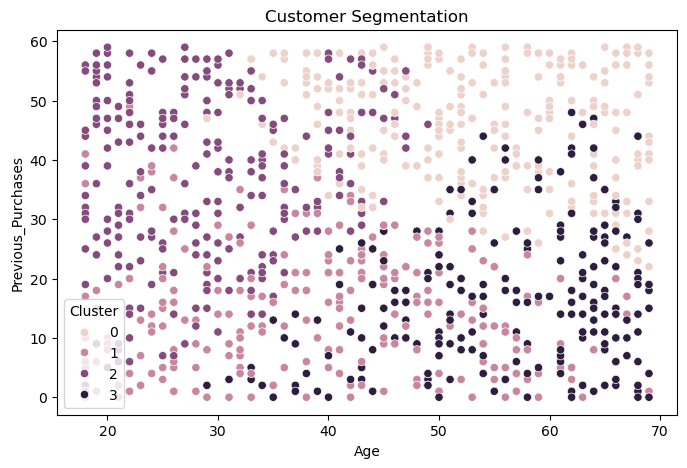

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=customers,
    x='Age',
    y='Previous_Purchases',
    hue='Cluster'
)

plt.title("Customer Segmentation")
plt.show()

In [18]:
X = customers[
    ['Age',
     'Previous_Purchases',
     'Review_Rating']
]

y = customers['Churn']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
predictions = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.785


In [23]:
sales.head()

,Transaction_ID,Date,Customer_ID,Product_ID,Quantity,Unit_Price,Revenue
0,1,2025-02-25,34,43,4,132.99,531.96
1,2,2025-01-03,636,37,3,19.13,57.39
2,3,2025-10-07,589,66,5,142.93,714.65
3,4,2025-07-11,904,27,3,83.31,249.93
4,5,2024-02-19,635,45,2,79.94,159.88


In [24]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  10000 non-null  int64  
 1   Date            10000 non-null  object 
 2   Customer_ID     10000 non-null  int64  
 3   Product_ID      10000 non-null  int64  
 4   Quantity        10000 non-null  int64  
 5   Unit_Price      10000 non-null  float64
 6   Revenue         10000 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 547.0+ KB


In [25]:
sales['Date'] = pd.to_datetime(sales['Date'])

In [26]:
daily_sales = sales.groupby('Date')['Revenue'].sum().reset_index()

daily_sales.head()

,Date,Revenue
0,2024-01-01,5166.81
1,2024-01-02,3305.27
2,2024-01-03,4161.29
3,2024-01-04,2784.20
4,2024-01-05,4468.70


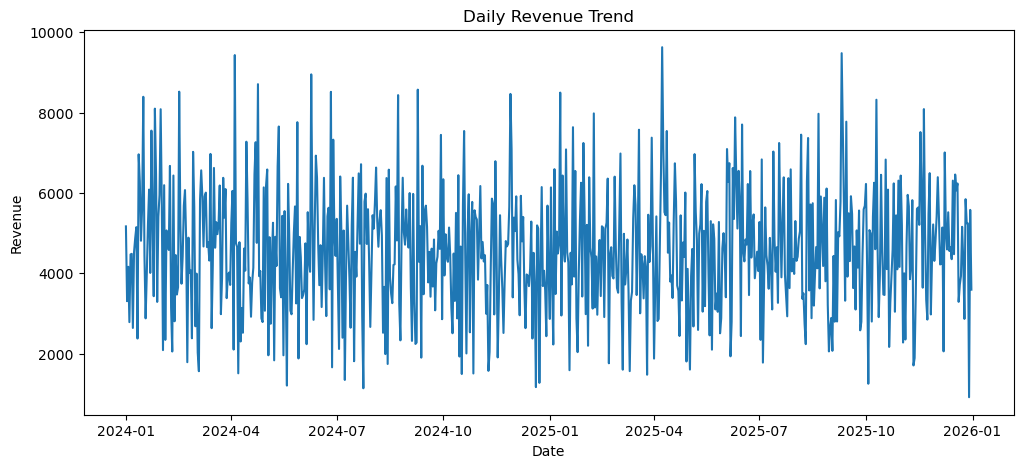

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    daily_sales['Date'],
    daily_sales['Revenue']
)

plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.show()

In [28]:
daily_sales['Day_Number'] = range(len(daily_sales))

In [29]:
daily_sales.head()

,Date,Revenue,Day_Number
0,2024-01-01,5166.81,0
1,2024-01-02,3305.27,1
2,2024-01-03,4161.29,2
3,2024-01-04,2784.20,3
4,2024-01-05,4468.70,4


In [30]:
from sklearn.linear_model import LinearRegression

X = daily_sales[['Day_Number']]
y = daily_sales['Revenue']

model = LinearRegression()

model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
future = pd.DataFrame({
    'Day_Number': range(
        len(daily_sales),
        len(daily_sales)+30
    )
})

forecast = model.predict(future)

print(forecast[:10])

[4593.97845155 4594.02798123 4594.07751091 4594.12704059 4594.17657027
 4594.22609995 4594.27562964 4594.32515932 4594.374689   4594.42421868]


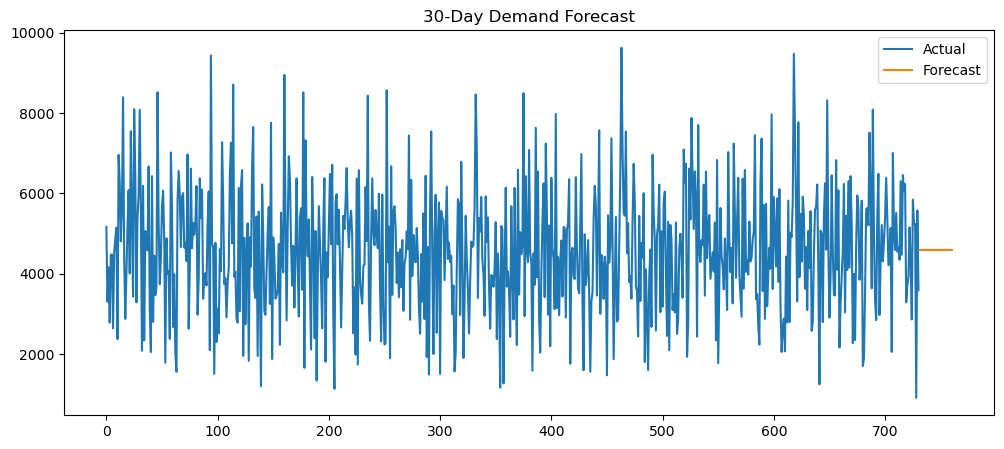

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_sales['Day_Number'],
    daily_sales['Revenue'],
    label='Actual'
)

plt.plot(
    future['Day_Number'],
    forecast,
    label='Forecast'
)

plt.legend()

plt.title("30-Day Demand Forecast")

plt.show()

In [33]:
inventory.head()

,Product_ID,Category,Stock_Level,Lead_Time_Days,Reorder_Point,Unit_Cost
0,1,Accessories,498,17,116,75.06
1,2,Footwear,339,18,100,29.02
2,3,Clothing,157,4,88,11.39
3,4,Outerwear,98,11,68,30.46
4,5,Outerwear,189,6,32,91.66


In [34]:
inventory.describe()

,Product_ID,Stock_Level,Lead_Time_Days,Reorder_Point,Unit_Cost
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,60.500000,237.658333,10.400000,89.408333,52.066583
std,34.785054,143.751741,5.137439,34.075669,28.093961
min,1.000000,21.000000,2.000000,30.000000,5.710000
25%,30.750000,110.750000,6.000000,61.750000,27.485000
50%,60.500000,207.500000,10.500000,87.000000,50.350000
75%,90.250000,369.000000,15.000000,116.250000,74.955000
max,120.000000,498.000000,19.000000,148.000000,99.940000


In [35]:
inventory['Need_Reorder'] = (
    inventory['Stock_Level'] <
    inventory['Reorder_Point']
)

inventory.head()

,Product_ID,Category,Stock_Level,Lead_Time_Days,Reorder_Point,Unit_Cost,Need_Reorder
0,1,Accessories,498,17,116,75.06,False
1,2,Footwear,339,18,100,29.02,False
2,3,Clothing,157,4,88,11.39,False
3,4,Outerwear,98,11,68,30.46,False
4,5,Outerwear,189,6,32,91.66,False


In [36]:
inventory['Need_Reorder'].value_counts()

Need_Reorder
False    97
True     23
Name: count, dtype: int64

In [37]:
reorder_products = inventory[
    inventory['Need_Reorder'] == True
]

reorder_products

,Product_ID,Category,Stock_Level,Lead_Time_Days,Reorder_Point,Unit_Cost,Need_Reorder
11,12,Clothing,35,16,77,64.54,True
17,18,Accessories,21,16,33,61.62,True
38,39,Outerwear,26,11,94,82.52,True
40,41,Outerwear,66,5,80,13.40,True
43,44,Clothing,57,8,136,64.82,True
48,49,Clothing,72,17,129,31.74,True
52,53,Clothing,67,10,81,60.17,True
56,57,Accessories,83,9,109,47.36,True
64,65,Outerwear,22,3,132,55.81,True
66,67,Accessories,48,2,68,50.08,True


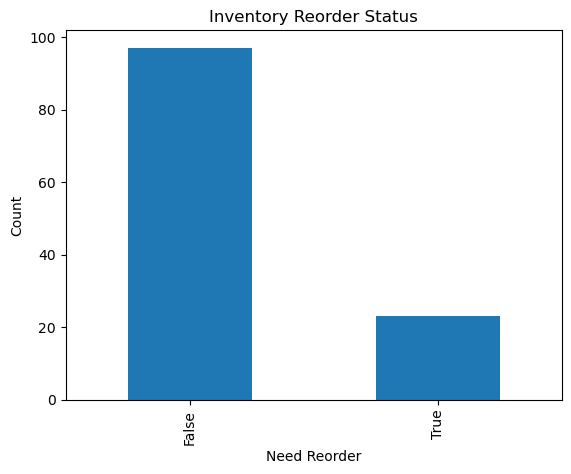

In [38]:
import matplotlib.pyplot as plt

inventory['Need_Reorder'].value_counts().plot(
    kind='bar'
)

plt.title("Inventory Reorder Status")
plt.xlabel("Need Reorder")
plt.ylabel("Count")

plt.show()

In [39]:
inventory['Suggested_Order'] = (
    inventory['Reorder_Point']
    - inventory['Stock_Level']
)

inventory['Suggested_Order'] = inventory[
    'Suggested_Order'
].clip(lower=0)

inventory.head()

,Product_ID,Category,Stock_Level,Lead_Time_Days,Reorder_Point,Unit_Cost,Need_Reorder,Suggested_Order
0,1,Accessories,498,17,116,75.06,False,0
1,2,Footwear,339,18,100,29.02,False,0
2,3,Clothing,157,4,88,11.39,False,0
3,4,Outerwear,98,11,68,30.46,False,0
4,5,Outerwear,189,6,32,91.66,False,0


In [40]:
inventory.sort_values(
    by='Suggested_Order',
    ascending=False
).head(10)

,Product_ID,Category,Stock_Level,Lead_Time_Days,Reorder_Point,Unit_Cost,Need_Reorder,Suggested_Order
64,65,Outerwear,22,3,132,55.81,True,110
75,76,Outerwear,58,13,144,44.65,True,86
43,44,Clothing,57,8,136,64.82,True,79
38,39,Outerwear,26,11,94,82.52,True,68
99,100,Accessories,70,18,130,73.22,True,60
48,49,Clothing,72,17,129,31.74,True,57
68,69,Accessories,30,11,83,46.05,True,53
11,12,Clothing,35,16,77,64.54,True,42
78,79,Footwear,65,17,107,6.58,True,42
96,97,Footwear,103,17,144,54.21,True,41


In [41]:
customers.to_csv(
    "customer_segments.csv",
    index=False
)

In [42]:
future['Forecast_Revenue'] = forecast

future.to_csv(
    "forecast_results.csv",
    index=False
)

In [43]:
inventory.to_csv(
    "inventory_recommendations.csv",
    index=False
)

In [1]:
plt.savefig("customer_segmentation.png")

NameError: name 'plt' is not defined

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=customers,
    x='Age',
    y='Previous_Purchases',
    hue='Cluster'
)

plt.title("Customer Segmentation")

plt.savefig("customer_segmentation.png")
plt.show()

NameError: name 'customers' is not defined

<Figure size 800x500 with 0 Axes>

In [3]:
plt.savefig("customer_segmentation.png")

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt

In [5]:
plt.savefig("age_distribution.png")

<Figure size 640x480 with 0 Axes>

In [6]:
plt.savefig("churn_distribution.png")

<Figure size 640x480 with 0 Axes>

In [7]:
plt.savefig("revenue_trend.png")

<Figure size 640x480 with 0 Axes>

In [8]:
plt.savefig("demand_forecast.png")

<Figure size 640x480 with 0 Axes>

In [9]:
plt.savefig("inventory_reorder.png")

<Figure size 640x480 with 0 Axes>